# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [42]:
!git clone https://github.com/nandini3206/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 142 (delta 52), reused 77 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (142/142), 1.89 MiB | 2.76 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [43]:
%cd flyrank-ml-internship

/content/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship


In [44]:
!pwd
!ls

/content/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship
AGENTS.md  DATA_USE.md	LICENSE    README.md	     SETUP.md	 work
CLAUDE.md  docs		notebooks  requirements.txt  skills
data	   GUIDE.md	outputs    scripts	     submission


In [45]:
!sed -n '1,200p' skills/README.md

# Skills — the router

This folder is a small library of **skills**: focused instruction files your AI assistant loads
one at a time. One skill per task keeps the assistant sharp — its context window is small, and
filling it with everything makes it worse at the one thing you need.

**How to use it (repo-reading agents — Claude Code, Cursor, Codex):** they find this file
automatically via `AGENTS.md` / `CLAUDE.md`. Just tell your assistant which task you're doing.

**Using a chat-only assistant (ChatGPT / Gemini in a browser)?** Open the skill file on GitHub,
copy its whole content, and paste it into your chat before asking for help. That's it.

## The table — find your task, load ONE skill

| Your task | Load this skill | Also load for data work |
|---|---|---|
| Any task — how to work with your assistant at all | `directing-your-ai-assistant/SKILL.md` | — |
| Pick a lane, frame your question (ML-02, ML-03) | `framing-ml-problems/SKILL.md` | `flyrank/flyrank-data/SKILL.md` |
| Write +

In [46]:
!sed -n '1,200p' skills/writing-honest-claims/SKILL.md

---
name: writing-honest-claims
description: Writes findings in language the evidence can carry — the claim ladder (observed → directional → decision-support, never causal without a design), effect sizes over drama, banned phrasings. Use when writing any conclusion, report section, playbook, or public page from analysis results.
---

# Writing honest claims

A finding is a sentence plus the evidence that carries it. Most analysis goes wrong in the
sentence, not the math: the words claim more than the numbers showed.

## The claim ladder — match words to evidence

| Evidence you actually have | Words you may use |
|---|---|
| A pattern in this dataset, this period | "we **observed**…", "in this data…" |
| A measured comparison between groups | "X is **associated with** Y", "pages with A **showed** B" |
| A validated model that ranks/predicts out-of-sample | "the model **ranks/flags**… at precision@K of…" |
| A controlled experiment or matched design | only THEN: "X **causes/improves** Y

In [47]:
!sed -n '1,200p' skills/flyrank/flyrank-data/SKILL.md

---
name: flyrank-data
description: The FlyRank internship datasets — the 30k-row starter CSV and its gotchas, the ~79M-row warehouse release tables and grains, panel warnings, access, and iteration rules. Load for EVERY task that touches the data. (Project-specific: delete this folder when reusing the skill library elsewhere.)
---

# FlyRank internship data

Two datasets. The small one ships in this repo; the big one is hosted and gated.

## 1. Starter dataset (in this repo)

`data/raw/content_refresh_anonymized.csv` — 30,000 rows × 44 columns, one row per pseudonymized
content item, 32 clients, trailing-90-day metrics. Full column reference: `docs/data-dictionary.md`
(keep it open). The gotchas that cause 90% of mistakes:

- **Rate columns are ×100 percentages**: `ctr = 0.76` means 0.76%, not 76%. Applies to ctr,
  engagement_rate, scroll_rate, ai_traffic_pct, trend_pct.
- **`avg_position = 0` means "no data"**, not rank zero (1,205 rows).
- **`scroll_rate` and `ai_traffic_pct` can e

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [48]:
import pandas as pd

queue = pd.read_csv("outputs/refresh_queue_sample.csv")

queue.head(10)

,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
5,6,content_b69288c5e701,client_3fdba35f04,80.754770,random_forest,0.795713,0.787358,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1370.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
6,7,content_9b6df29f7889,client_3fdba35f04,80.632923,random_forest,0.846245,0.673530,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1415.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,moderate,page_1
7,8,content_bb6ebb5ec8c8,client_3fdba35f04,80.371236,random_forest,0.834638,0.690665,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1381.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
8,9,content_4d76cdb3387b,client_3fdba35f04,80.362748,random_forest,0.843092,0.671993,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1554.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,moderate,top_3
9,10,content_b4f35d640b1c,client_3fdba35f04,80.321757,random_forest,0.843803,0.669168,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1389.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,good,page_3_5


## Ranked actions + reason codes

The refresh queue ranks content by priority using the final refresh score. Higher-ranked pages should be reviewed first because they are more likely to benefit from content refresh.

Each recommendation includes a reason code and a confidence level to explain why the page appears in the queue. These recommendations are intended to support human decision-making rather than automate actions.

In [49]:
print(queue.columns.tolist())

['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


In [50]:
display(
    queue[
        [
            "final_rank",
            "final_refresh_score",
            "suggested_action",
            "confidence",
            "best_model_probability"
        ]
    ].head(10)
)

,final_rank,final_refresh_score,suggested_action,confidence,best_model_probability
0,1,81.636697,refresh_and_review_ctr,high,0.782079
1,2,81.447656,refresh_and_review_ctr,high,0.788105
2,3,81.430346,refresh_and_review_ctr,medium,0.847372
3,4,81.034960,refresh_and_review_ctr,high,0.774371
4,5,80.873188,refresh_and_review_ctr,medium,0.814805
5,6,80.754770,refresh_and_review_ctr,high,0.795713
6,7,80.632923,refresh_and_review_ctr,high,0.846245
7,8,80.371236,refresh_and_review_ctr,high,0.834638
8,9,80.362748,refresh_and_review_ctr,medium,0.843092
9,10,80.321757,refresh,medium,0.843803


### Observation

The queue is ranked by the final refresh score, with higher-priority pages appearing first. Most of the top-ranked pages are assigned the **refresh_and_review_ctr** action, while some are marked as **refresh**.

The confidence level indicates how certain the model is about each recommendation. These results should be used as decision-support rather than automatic decisions. A human reviewer should verify the recommendation before making content changes.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [51]:
print("Suggested Actions:")
print(queue["suggested_action"].value_counts())

print("\nConfidence Levels:")
print(queue["confidence"].value_counts())

Suggested Actions:
suggested_action
refresh_and_review_ctr           130
refresh                           35
refresh_and_review_engagement     35
Name: count, dtype: int64

Confidence Levels:
confidence
high      161
medium     39
Name: count, dtype: int64


## Intended use and limits

This refresh queue is designed to help content teams prioritize which pages should be reviewed first. The model ranks pages using the final refresh score and provides a suggested action with a confidence level.

The recommendations are intended for decision-support rather than fully automated execution. Editors should review the content before making updates.

The results are valid only for data similar to the training dataset. Changes in website structure, user behavior, or search engine algorithms may reduce the reliability of these recommendations.

In [52]:
queue["suggested_action"].unique()

array(['refresh_and_review_ctr', 'refresh',
       'refresh_and_review_engagement'], dtype=object)

### Limitations

- The model provides recommendations based on historical data.
- High confidence does not guarantee that a refresh will improve performance.
- Human review is required before publishing any content changes.
- The recommendations should not replace editorial judgment.
- The model should be re-evaluated when new data becomes available or website conditions change.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [53]:
queue[
    [
        "final_rank",
        "suggested_action",
        "confidence",
        "best_model_probability"
    ]
].head(10)

,final_rank,suggested_action,confidence,best_model_probability
0,1,refresh_and_review_ctr,high,0.782079
1,2,refresh_and_review_ctr,high,0.788105
2,3,refresh_and_review_ctr,medium,0.847372
3,4,refresh_and_review_ctr,high,0.774371
4,5,refresh_and_review_ctr,medium,0.814805
5,6,refresh_and_review_ctr,high,0.795713
6,7,refresh_and_review_ctr,high,0.846245
7,8,refresh_and_review_ctr,high,0.834638
8,9,refresh_and_review_ctr,medium,0.843092
9,10,refresh,medium,0.843803


## Human review + the no-go list

Before applying any recommendation, a human reviewer should verify that the content is still relevant, accurate, and aligned with current business goals.

The suggested action should be considered as decision-support rather than a final decision. Even recommendations with high confidence require editorial review before implementation.

### No-go list

- Do not automatically publish content changes.
- Do not remove or rewrite pages without human review.
- Do not rely only on model confidence when making decisions.
- Do not use the recommendations outside the intended dataset or business context.
- Always verify important pages manually before taking action.

<Axes: xlabel='confidence'>

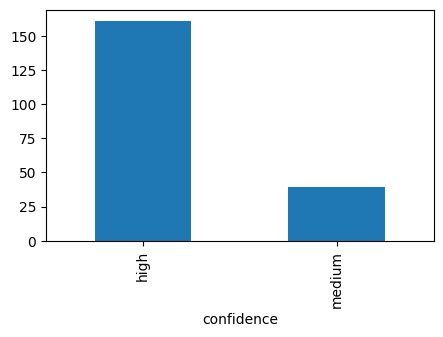

In [54]:
queue["confidence"].value_counts().plot.bar(figsize=(5,3))

### Observation

Most recommendations have a **high** confidence level, while a smaller number are marked as **medium** confidence.

Although the model provides useful prioritization, all recommendations should be reviewed by a human before any content changes are made. This helps prevent incorrect or unnecessary updates.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [55]:
queue["confidence"].value_counts()

,count
confidence,
high,161
medium,39


## Monitoring / retrain triggers

The refresh recommendations should be monitored regularly to ensure that the model continues to perform well.

Possible retraining or review triggers include:

- A noticeable drop in model confidence.
- Significant changes in website traffic or user behavior.
- Major search engine algorithm updates.
- Changes in content strategy or business objectives.
- New training data becoming available.

The model should be evaluated periodically to confirm that its recommendations remain reliable.

<Axes: title={'center': 'Confidence Distribution'}, xlabel='confidence'>

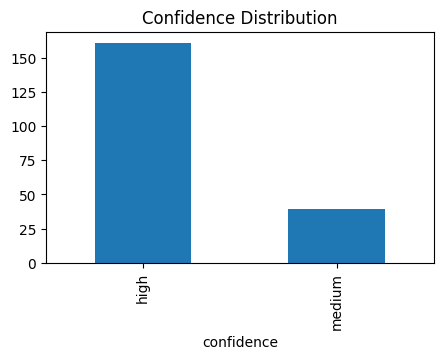

In [56]:
queue["confidence"].value_counts().plot(
    kind="bar",
    figsize=(5,3),
    title="Confidence Distribution"
)

### Observation

Most recommendations are classified as **high confidence**, while a smaller number are **medium confidence**.

If future refresh queues contain a much larger proportion of medium or low-confidence recommendations, the model should be reviewed and retrained before being used for decision support.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [57]:
from pathlib import Path

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

queue.to_csv(output_dir / "refresh_queue_export.csv", index=False)

print("Export completed!")
print(output_dir / "refresh_queue_export.csv")

Export completed!
work/outputs/refresh_queue_export.csv


## Export Summary

The ranked refresh queue has been exported for use in the final research paper.

The exported file contains the ranked content recommendations, suggested actions, confidence levels, and model scores. These outputs can be reused for reporting and future analysis.

This export supports reproducibility by preserving the model outputs used in this notebook.

In [58]:
import os

print(os.listdir("work/outputs"))

['refresh_queue_export.csv']


### Observation

The refresh queue was successfully exported to the `work/outputs` directory.

This file can be reused in later stages of the project, including the final research paper and reporting notebooks.

## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.